In [1]:
import random
import polars as pl
from utilsforecast.plotting import plot_series

In [2]:
# Phase 0 - Sales.csv
phase1_url = 'https://www.datasource.ai/attachments/eyJpZCI6Ijk4NDYxNjE2NmZmZjM0MGRmNmE4MTczOGMyMzI2ZWI2LmNzdiIsInN0b3JhZ2UiOiJzdG9yZSIsIm1ldGFkYXRhIjp7ImZpbGVuYW1lIjoiUGhhc2UgMCAtIFNhbGVzLmNzdiIsInNpemUiOjEwODA0NjU0LCJtaW1lX3R5cGUiOiJ0ZXh0L2NzdiJ9fQ'
phase1 = pl.read_csv(phase1_url).sort('Client', 'Warehouse', 'Product')
phase1

Client,Warehouse,Product,2020-07-06,2020-07-13,2020-07-20,2020-07-27,2020-08-03,2020-08-10,2020-08-17,2020-08-24,2020-08-31,2020-09-07,2020-09-14,2020-09-21,2020-09-28,2020-10-05,2020-10-12,2020-10-19,2020-10-26,2020-11-02,2020-11-09,2020-11-16,2020-11-23,2020-11-30,2020-12-07,2020-12-14,2020-12-21,2020-12-28,2021-01-04,2021-01-11,2021-01-18,2021-01-25,2021-02-01,2021-02-08,2021-02-15,2021-02-22,…,2023-01-23,2023-01-30,2023-02-06,2023-02-13,2023-02-20,2023-02-27,2023-03-06,2023-03-13,2023-03-20,2023-03-27,2023-04-03,2023-04-10,2023-04-17,2023-04-24,2023-05-01,2023-05-08,2023-05-15,2023-05-22,2023-05-29,2023-06-05,2023-06-12,2023-06-19,2023-06-26,2023-07-03,2023-07-10,2023-07-17,2023-07-24,2023-07-31,2023-08-07,2023-08-14,2023-08-21,2023-08-28,2023-09-04,2023-09-11,2023-09-18,2023-09-25,2023-10-02
i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1,367,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,1.0,0.0,…,3.0,2.0,1.0,2.0,2.0,3.0,0.0,2.0,2.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,7.0,0.0
0,1,639,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,15.0,5.0,5.0,4.0,14.0,8.0,2.0,11.0,7.0,5.0,8.0,4.0,4.0,5.0,4.0,1.0,3.0,8.0,8.0,1.0,1.0,7.0,2.0,7.0,3.0,6.0,2.0,3.0,5.0,5.0,6.0,5.0,1.0,2.0,2.0,18.0,2.0
0,1,655,21.0,21.0,21.0,25.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,31.0,28.0,28.0,28.0,28.0,28.0,28.0,28.0,28.0,34.0,35.0,35.0,35.0,29.0,21.0,21.0,21.0,21.0,21.0,21.0,3.0,0.0,…,10.0,14.0,8.0,3.0,12.0,12.0,6.0,15.0,14.0,8.0,9.0,3.0,4.0,13.0,3.0,5.0,3.0,10.0,11.0,4.0,4.0,11.0,9.0,3.0,4.0,4.0,6.0,9.0,4.0,2.0,9.0,8.0,6.0,0.0,17.0,21.0,37.0
0,1,1149,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,1.0,0.0,…,0.0,1.0,1.0,2.0,1.0,5.0,0.0,2.0,0.0,0.0,2.0,3.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,2.0,1.0,0.0,1.0
0,1,1485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.0,23.0,4.0,2.0,2.0,3.0,1.0,6.0,2.0,3.0,1.0,11.0,9.0,5.0,0.0,7.0,18.0,2.0,0.0,1.0,21.0,23.0,2.0,1.0,1.0,2.0,0.0,22.0,10.0,6.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
46,318,13485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,52.0,68.0,78.0,78.0,78.0,79.0,77.0,86.0,99.0,77.0,54.0,55.0,69.0,37.0,2.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,24.0,38.0,42.0,49.0,0.0,33.0,61.0,67.0,63.0,48.0,80.0
46,318,13582,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,16.0,12.0,37.0,73.0,72.0,59.0,42.0,44.0,39.0,66.0,56.0,70.0,37.0,44.0,30.0,23.0,28.0,18.0,19.0,10.0,8.0,17.0,29.0,15.0,49.0,22.0,26.0,33.0,18.0,20.0,1.0,14.0,41.0,25.0,34.0,30.0,39.0
46,318,13691,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,13.0,10.0,17.0,11.0,16.0,12.0,11.0,12.0,9.0,14.0,24.0,31.0,21.0,25.0,22.0,28.0,21.0,21.0,10.0,1.0,1.0,0.0,0.0,2.0,4.0,1.0,3.0,6.0,1.0,2.0,0.0,0.0,0.0,1.0,4.0,3.0,1.0


In [3]:
# Phase 1 - Sales.csv
phase2_url = 'https://www.datasource.ai/attachments/eyJpZCI6ImM2OGQxNGNmNTJkZDQ1MTUyZTg0M2FkMDAyMjVlN2NlLmNzdiIsInN0b3JhZ2UiOiJzdG9yZSIsIm1ldGFkYXRhIjp7ImZpbGVuYW1lIjoiUGhhc2UgMSAtIFNhbGVzLmNzdiIsInNpemUiOjEwMTgzOTYsIm1pbWVfdHlwZSI6InRleHQvY3N2In19'
phase2 = pl.read_csv(phase2_url).sort('Client', 'Warehouse', 'Product').drop('Client', 'Warehouse', 'Product')
phase2

2023-10-09,2023-10-16,2023-10-23,2023-10-30,2023-11-06,2023-11-13,2023-11-20,2023-11-27,2023-12-04,2023-12-11,2023-12-18,2023-12-25,2024-01-01
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,1.0,1.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5.0,4.0,3.0,4.0,2.0,6.0,3.0,4.0,1.0,2.0,4.0,5.0,3.0
6.0,4.0,2.0,1.0,1.0,2.0,0.0,3.0,2.0,2.0,2.0,2.0,4.0
1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,2.0,0.0,1.0,0.0
0.0,6.0,42.0,4.0,4.0,1.0,1.0,4.0,24.0,4.0,1.0,3.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…
89.0,132.0,98.0,78.0,89.0,71.0,80.0,42.0,5.0,1.0,0.0,3.0,0.0
214.0,174.0,118.0,40.0,40.0,40.0,30.0,29.0,22.0,25.0,21.0,61.0,67.0
4.0,8.0,9.0,2.0,2.0,3.0,3.0,4.0,7.0,1.0,1.0,0.0,2.0


In [4]:
wide = pl.concat([phase1, phase2], how='horizontal')
wide

Client,Warehouse,Product,2020-07-06,2020-07-13,2020-07-20,2020-07-27,2020-08-03,2020-08-10,2020-08-17,2020-08-24,2020-08-31,2020-09-07,2020-09-14,2020-09-21,2020-09-28,2020-10-05,2020-10-12,2020-10-19,2020-10-26,2020-11-02,2020-11-09,2020-11-16,2020-11-23,2020-11-30,2020-12-07,2020-12-14,2020-12-21,2020-12-28,2021-01-04,2021-01-11,2021-01-18,2021-01-25,2021-02-01,2021-02-08,2021-02-15,2021-02-22,…,2023-04-24,2023-05-01,2023-05-08,2023-05-15,2023-05-22,2023-05-29,2023-06-05,2023-06-12,2023-06-19,2023-06-26,2023-07-03,2023-07-10,2023-07-17,2023-07-24,2023-07-31,2023-08-07,2023-08-14,2023-08-21,2023-08-28,2023-09-04,2023-09-11,2023-09-18,2023-09-25,2023-10-02,2023-10-09,2023-10-16,2023-10-23,2023-10-30,2023-11-06,2023-11-13,2023-11-20,2023-11-27,2023-12-04,2023-12-11,2023-12-18,2023-12-25,2024-01-01
i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1,367,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,1.0,0.0,…,2.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,7.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
0,1,639,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,5.0,4.0,1.0,3.0,8.0,8.0,1.0,1.0,7.0,2.0,7.0,3.0,6.0,2.0,3.0,5.0,5.0,6.0,5.0,1.0,2.0,2.0,18.0,2.0,5.0,4.0,3.0,4.0,2.0,6.0,3.0,4.0,1.0,2.0,4.0,5.0,3.0
0,1,655,21.0,21.0,21.0,25.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,31.0,28.0,28.0,28.0,28.0,28.0,28.0,28.0,28.0,34.0,35.0,35.0,35.0,29.0,21.0,21.0,21.0,21.0,21.0,21.0,3.0,0.0,…,13.0,3.0,5.0,3.0,10.0,11.0,4.0,4.0,11.0,9.0,3.0,4.0,4.0,6.0,9.0,4.0,2.0,9.0,8.0,6.0,0.0,17.0,21.0,37.0,6.0,4.0,2.0,1.0,1.0,2.0,0.0,3.0,2.0,2.0,2.0,2.0,4.0
0,1,1149,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,1.0,0.0,…,0.0,0.0,1.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,2.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,2.0,0.0,1.0,0.0
0,1,1485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,1.0,6.0,2.0,3.0,1.0,11.0,9.0,5.0,0.0,7.0,18.0,2.0,0.0,1.0,21.0,23.0,2.0,1.0,1.0,2.0,0.0,22.0,10.0,6.0,0.0,6.0,42.0,4.0,4.0,1.0,1.0,4.0,24.0,4.0,1.0,3.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
46,318,13485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,37.0,2.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,24.0,38.0,42.0,49.0,0.0,33.0,61.0,67.0,63.0,48.0,80.0,89.0,132.0,98.0,78.0,89.0,71.0,80.0,42.0,5.0,1.0,0.0,3.0,0.0
46,318,13582,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,44.0,30.0,23.0,28.0,18.0,19.0,10.0,8.0,17.0,29.0,15.0,49.0,22.0,26.0,33.0,18.0,20.0,1.0,14.0,41.0,25.0,34.0,30.0,39.0,214.0,174.0,118.0,40.0,40.0,40.0,30.0,29.0,22.0,25.0,21.0,61.0,67.0
46,318,13691,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,25.0,22.0,28.0,21.0,21.0,10.0,1.0,1.0,0.0,0.0,2.0,4.0,1.0,3.0,6.0,1.0,2.0,0.0,0.0,0.0,1.0,4.0,3.0,1.0,4.0,8.0,9.0,2.0,2.0,3.0,3.0,4.0,7.0,1.0,1.0,0.0,2.0


In [5]:
sales = wide.unpivot(index=['Client', 'Warehouse', 'Product'], variable_name='ds', value_name='y')
sales = sales.with_columns(
    unique_id= 'C'+ pl.col('Client').cast(pl.Utf8) + '_' + 'W'+ pl.col('Warehouse').cast(pl.Utf8) + '_' + 'P' + pl.col('Product').cast(pl.Utf8),
    ds=pl.col('ds').cast(pl.Date)
)
sales = sales.select('unique_id', 'ds', 'y')
sales

unique_id,ds,y
str,date,f64
"""C0_W1_P367""",2020-07-06,7.0
"""C0_W1_P639""",2020-07-06,0.0
"""C0_W1_P655""",2020-07-06,21.0
"""C0_W1_P1149""",2020-07-06,7.0
"""C0_W1_P1485""",2020-07-06,0.0
…,…,…
"""C46_W318_P13485""",2024-01-01,0.0
"""C46_W318_P13582""",2024-01-01,67.0
"""C46_W318_P13691""",2024-01-01,2.0


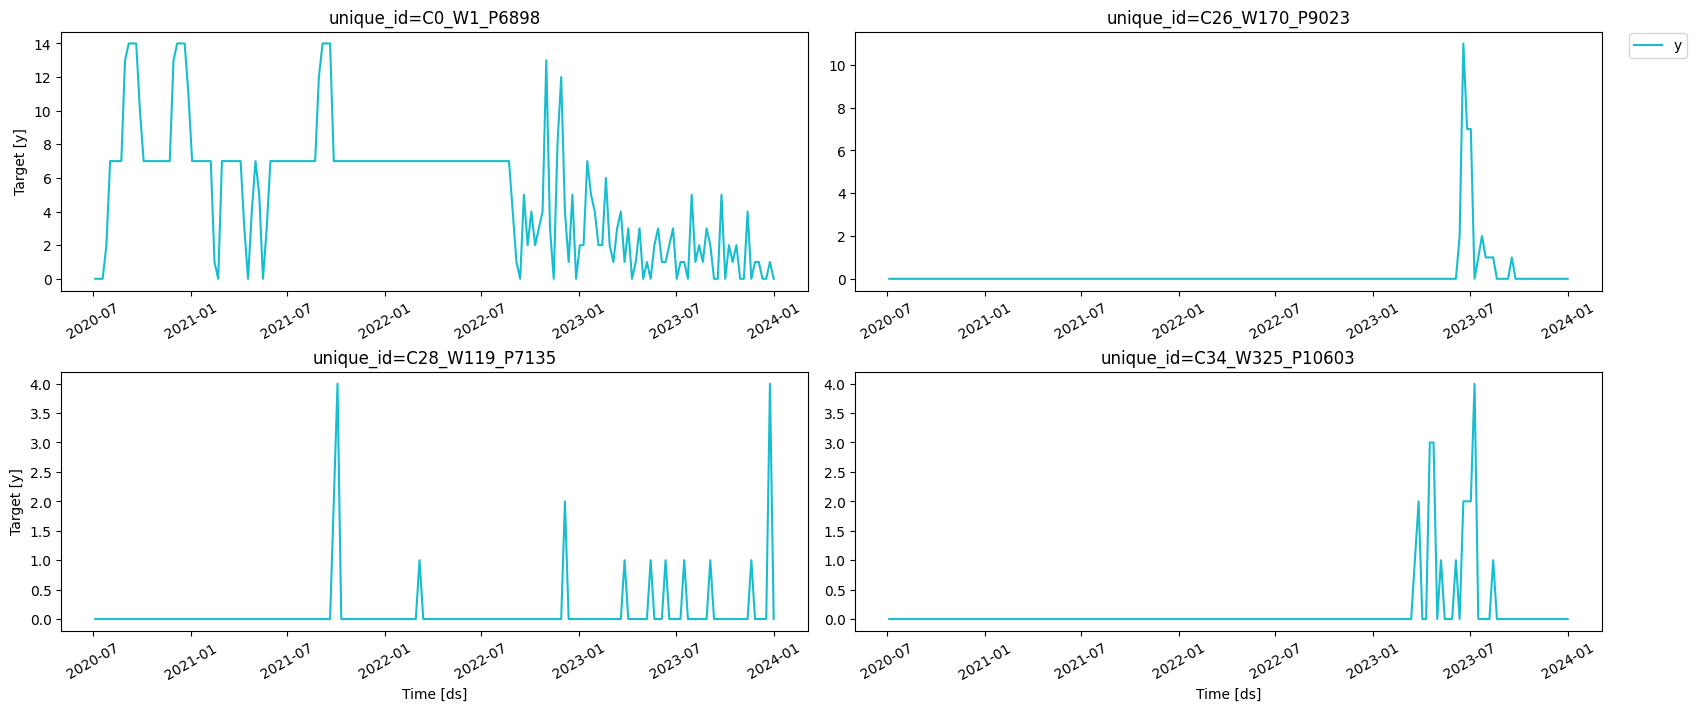

In [6]:
plot_series(sales, seed=random.randint(0, 2000), max_ids=4)

# Removing Leading Zeros

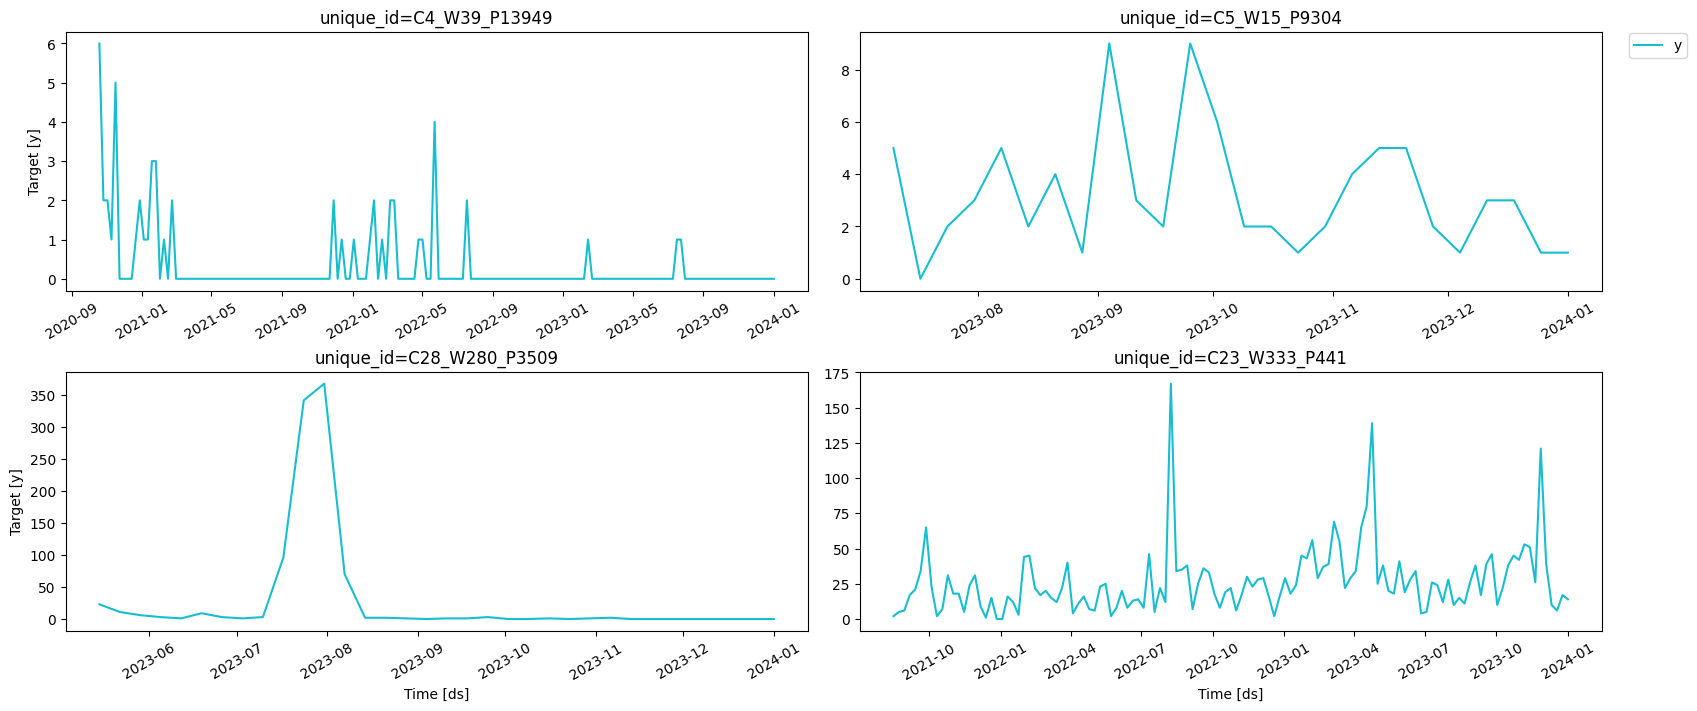

In [7]:
sales = sales.sort('unique_id', 'ds')
without_leading_zeros = sales.select(pl.col('y').gt(0).cast(pl.Int64).cum_max().over('unique_id').cast(pl.Boolean))['y']
sales = sales.filter(without_leading_zeros)
plot_series(sales, seed=random.randint(0, 2000), max_ids=4)

In [8]:
sales

unique_id,ds,y
str,date,f64
"""C0_W100_P10705""",2020-07-06,7.0
"""C0_W100_P10705""",2020-07-13,7.0
"""C0_W100_P10705""",2020-07-20,7.0
"""C0_W100_P10705""",2020-07-27,7.0
"""C0_W100_P10705""",2020-08-03,7.0
…,…,…
"""C9_W82_P9950""",2023-12-04,0.0
"""C9_W82_P9950""",2023-12-11,0.0
"""C9_W82_P9950""",2023-12-18,0.0


In [9]:
sales.write_csv("./data/train_data.csv")

In [11]:
# Phase 2 - Sales.csv
test = pl.read_csv('./data/Phase 2 - Sales.csv').sort('Client', 'Warehouse', 'Product')

In [12]:
wide = pl.concat([test], how='horizontal')
wide

Client,Warehouse,Product,2024-01-08,2024-01-15,2024-01-22,2024-01-29,2024-02-05,2024-02-12,2024-02-19,2024-02-26,2024-03-04,2024-03-11,2024-03-18,2024-03-25,2024-04-01
i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1,367,0.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
0,1,639,2.0,6.0,1.0,9.0,0.0,1.0,2.0,7.0,0.0,1.0,3.0,4.0,2.0
0,1,655,1.0,4.0,2.0,3.0,6.0,1.0,1.0,4.0,7.0,0.0,1.0,3.0,0.0
0,1,1149,0.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
0,1,1485,3.0,1.0,1.0,16.0,4.0,6.0,3.0,21.0,0.0,2.0,1.0,8.0,12.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
46,318,13485,0.0,0.0,0.0,1.0,0.0,22.0,13.0,1.0,1.0,20.0,52.0,63.0,87.0
46,318,13582,104.0,177.0,114.0,93.0,175.0,214.0,181.0,136.0,156.0,103.0,116.0,122.0,105.0
46,318,13691,1.0,1.0,2.0,1.0,1.0,1.0,6.0,3.0,0.0,5.0,1.0,8.0,0.0


In [13]:
sales_test = wide.unpivot(index=['Client', 'Warehouse', 'Product'], variable_name='ds', value_name='y')
sales_test = sales_test.with_columns(
    unique_id= 'C'+ pl.col('Client').cast(pl.Utf8) + '_' + 'W'+ pl.col('Warehouse').cast(pl.Utf8) + '_' + 'P' + pl.col('Product').cast(pl.Utf8),
    ds=pl.col('ds').cast(pl.Date)
)
sales_test = sales_test.select('unique_id', 'ds', 'y')
sales_test

unique_id,ds,y
str,date,f64
"""C0_W1_P367""",2024-01-08,0.0
"""C0_W1_P639""",2024-01-08,2.0
"""C0_W1_P655""",2024-01-08,1.0
"""C0_W1_P1149""",2024-01-08,0.0
"""C0_W1_P1485""",2024-01-08,3.0
…,…,…
"""C46_W318_P13485""",2024-04-01,87.0
"""C46_W318_P13582""",2024-04-01,105.0
"""C46_W318_P13691""",2024-04-01,0.0


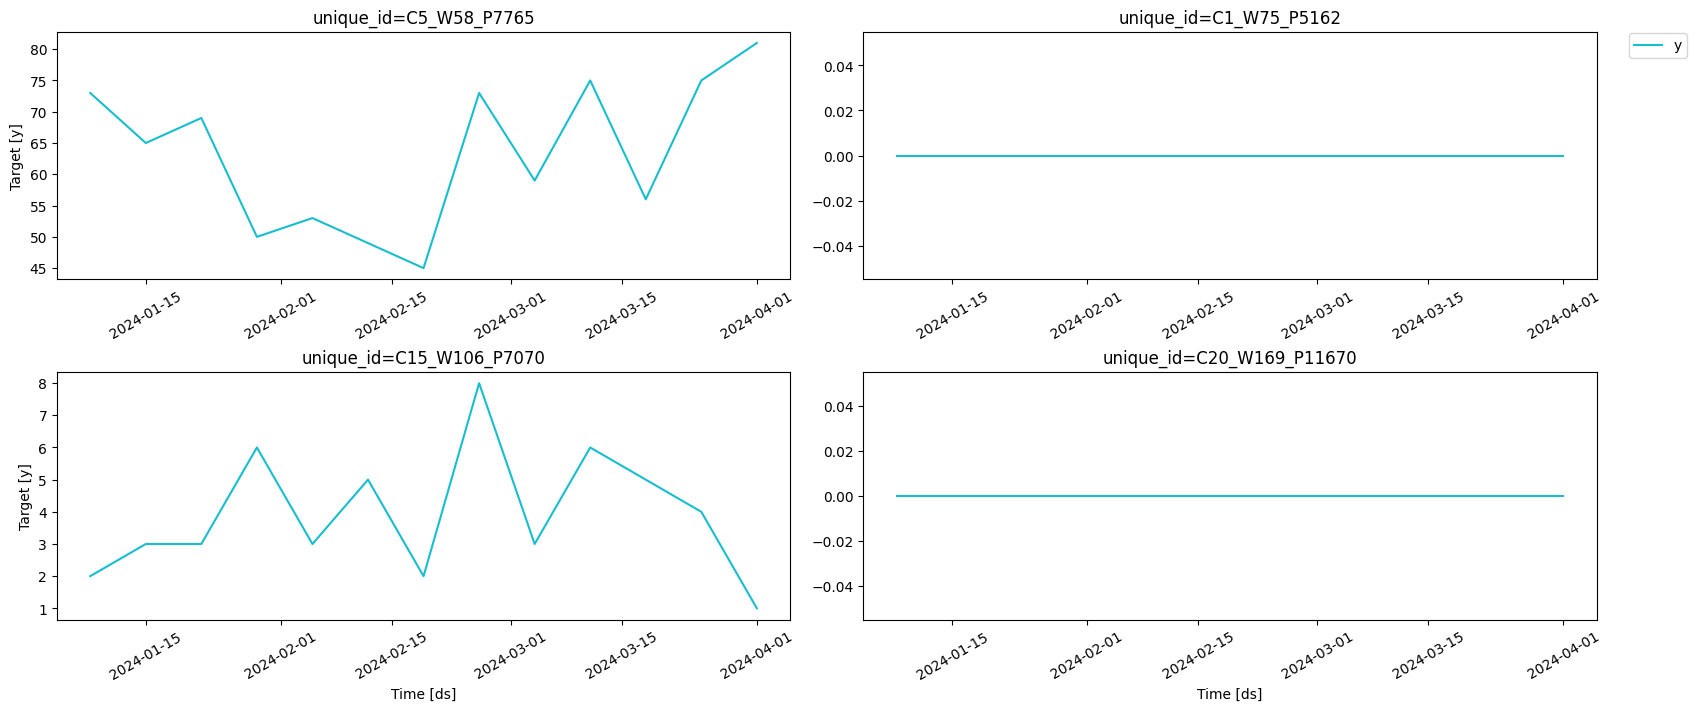

In [14]:
plot_series(sales_test, seed=random.randint(0, 2000), max_ids=4)

In [15]:
sales_test.write_csv("./data/test.csv")

In [ ]:
#conda install conda-forge::polars
